# TODO
- deep known about dataset
- feature engineering
- model building

### Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Suppress warnings
Configure the warnings module to ignore non‑critical warnings.

In [2]:
import warnings

warnings.filterwarnings("ignore")

### Pull dataset and anomalies from database

In [3]:
df = pd.read_csv("onlinefraud.csv")
df = df.drop(columns= "isFlaggedFraud")

craw = df
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


## Exploratory Data Analysis (EDA)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 657.7 MB


In [5]:
df.shape

(6362620, 10)

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

- The dataset contains no missing values

In [7]:
df.duplicated().sum()

np.int64(0)

- No duplicate transactions were found in the dataset.

In [8]:
# Use smaller dtype for numberical columns
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = pd.to_numeric(df[col], downcast= 'float')
    if df[col].dtype == 'int64':
        df[col] = pd.to_numeric(df[col], downcast= 'unsigned')
        
df['type'] = df['type'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            uint16  
 1   type            category
 2   amount          float64 
 3   nameOrig        str     
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        str     
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         uint8   
dtypes: category(1), float64(5), str(2), uint16(1), uint8(1)
memory usage: 491.3 MB


In [9]:
df.describe(include= [np.number]).T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [10]:
df.describe(include= ['str', 'category']).T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C2098525306,3
nameDest,6362620,2722362,C1286084959,113


In [11]:
df['nameOrig'].value_counts()

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
              ..
C786484425     1
C1529008245    1
C1162922333    1
C1685995037    1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

- There are 6,353,307 unique customers initiating transactions.

In [12]:
df['nameDest'].value_counts()

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

- There are 2,722,362 unique transaction recipients.

In [13]:
for i in df.select_dtypes(include= "category").columns:
    print(df[i].value_counts())
    print("***" * 10)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
******************************


### Graphs

In [14]:
# Setting
sns.set_style('whitegrid')

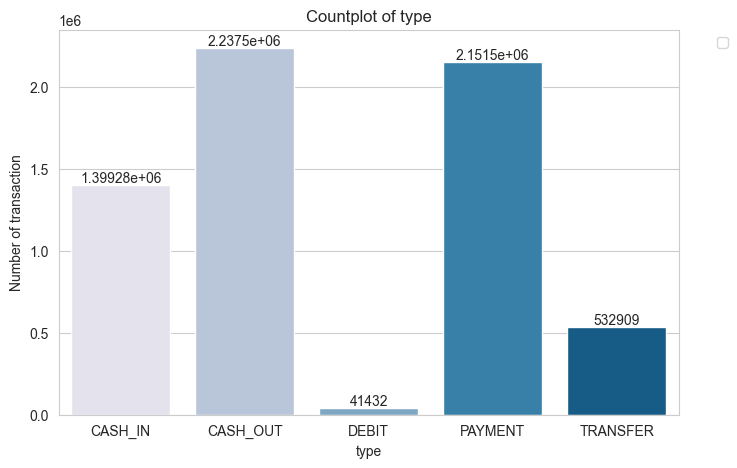

In [15]:
col = 'type'

plt.figure(figsize=(8, 5))

ax = sns.countplot(x=col, data=df, palette= 'PuBu')

for container in ax.containers:
    ax.bar_label(container)

# plt.grid(axis='y', alpha= 0.5)
plt.title(f'Countplot of {col}')
plt.ylabel('Number of transaction')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

- Cash Out is the most frequent transaction type, followed by Payment, Cash In, Transfer, and Debit.

In [31]:
numberic_cols = df.select_dtypes(include= 'number').columns
numberic_cols

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud'],
      dtype='str')

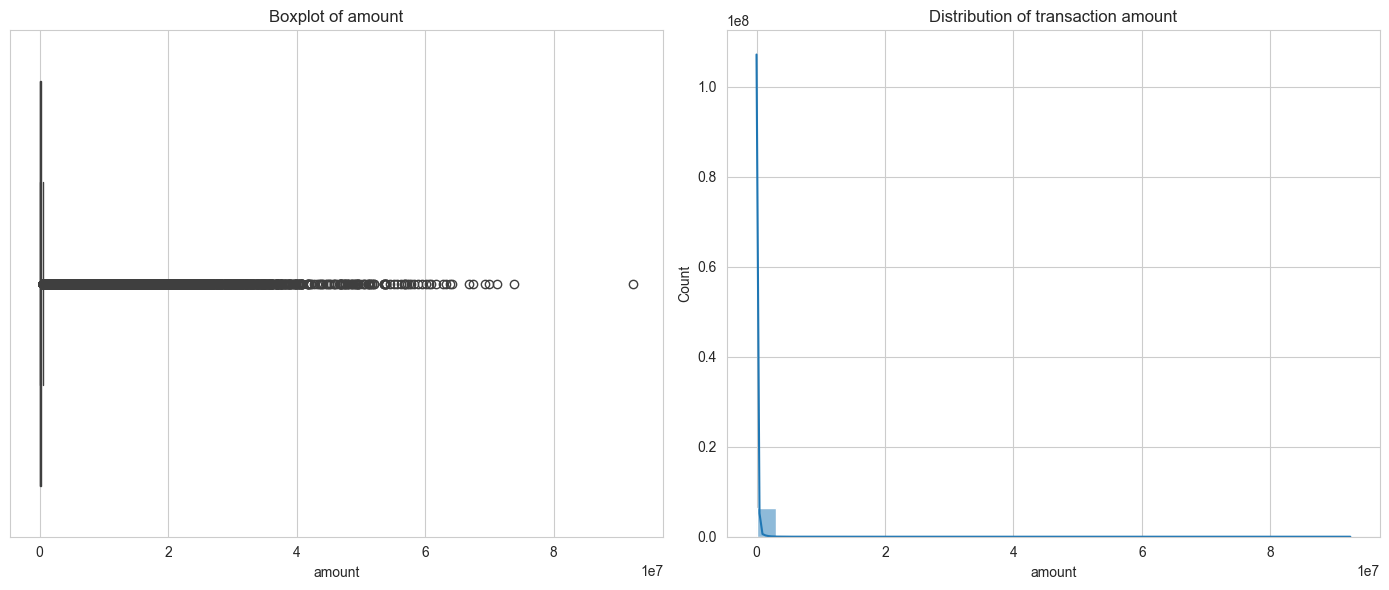

In [17]:
col = 'amount'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- Most transactions occur with relatively low transaction amounts.

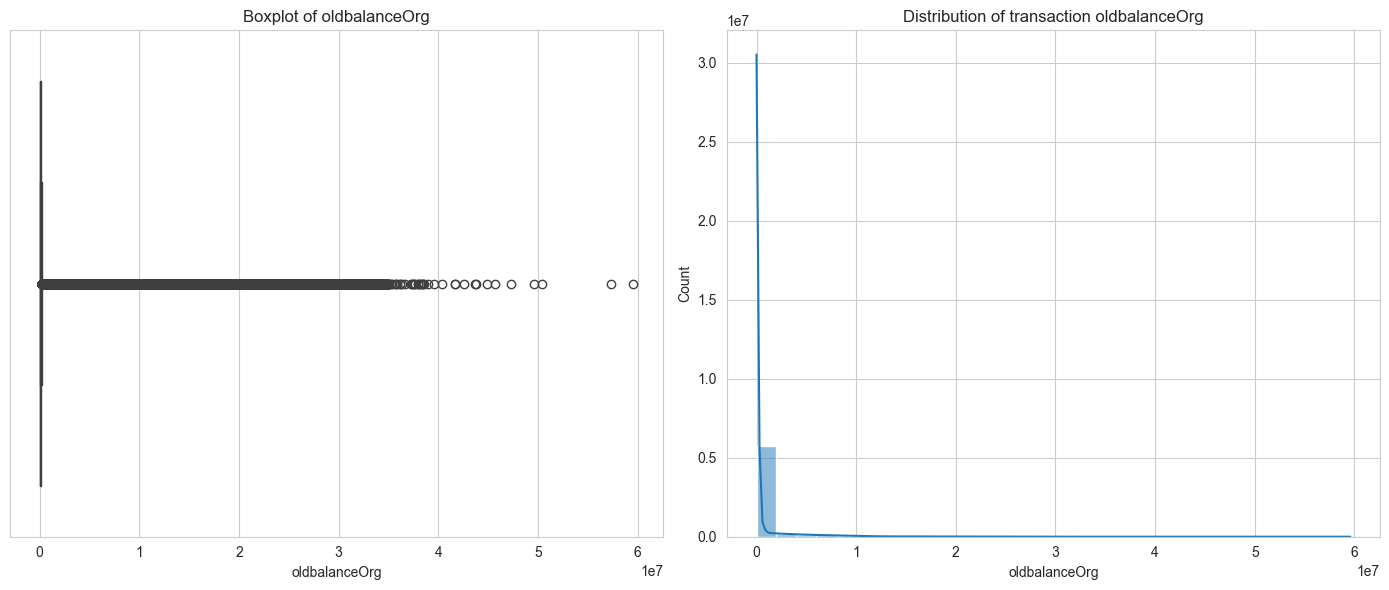

In [18]:
col = 'oldbalanceOrg'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of customer balances before transactions is heavily right-skewed.

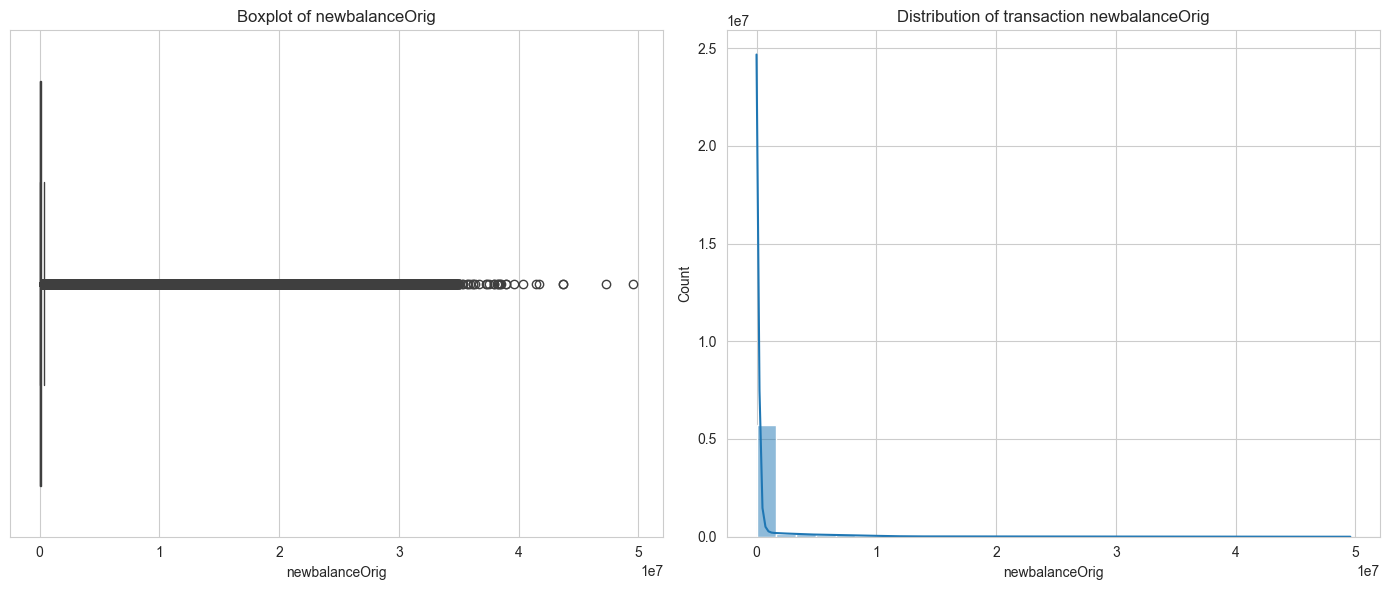

In [19]:
col = 'newbalanceOrig'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of customer balances after transactions is highly right-skewed.

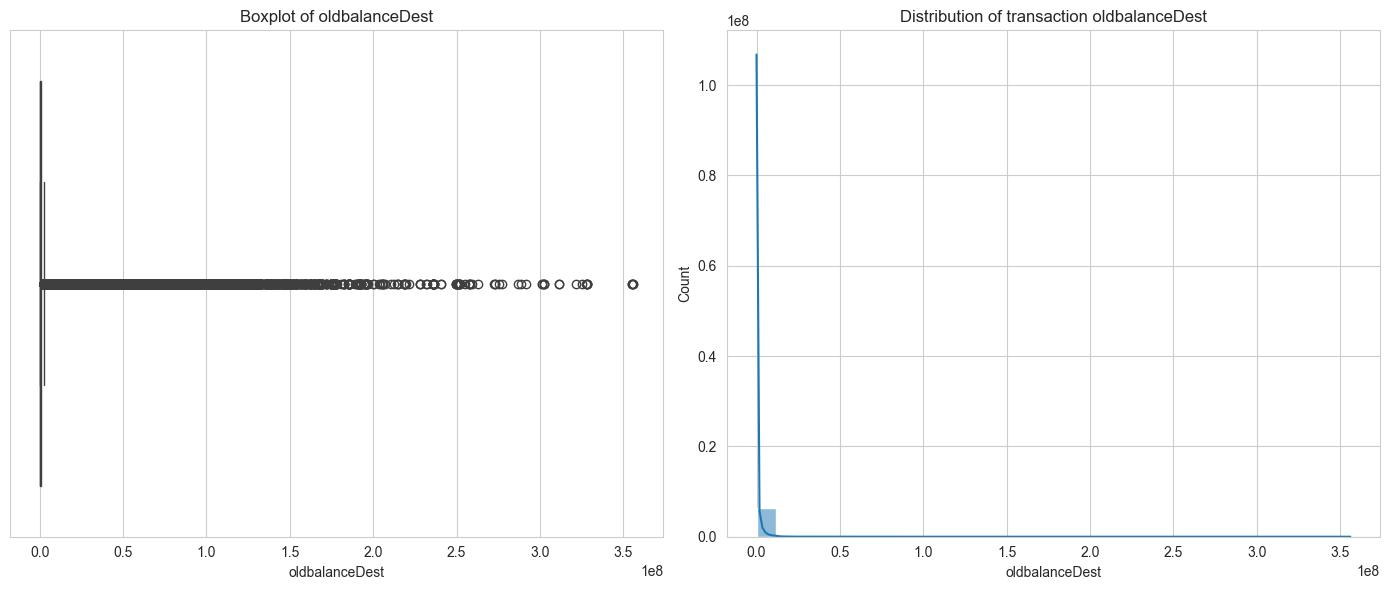

In [20]:
col = 'oldbalanceDest'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of recipient balances before transactions is highly right-skewed.

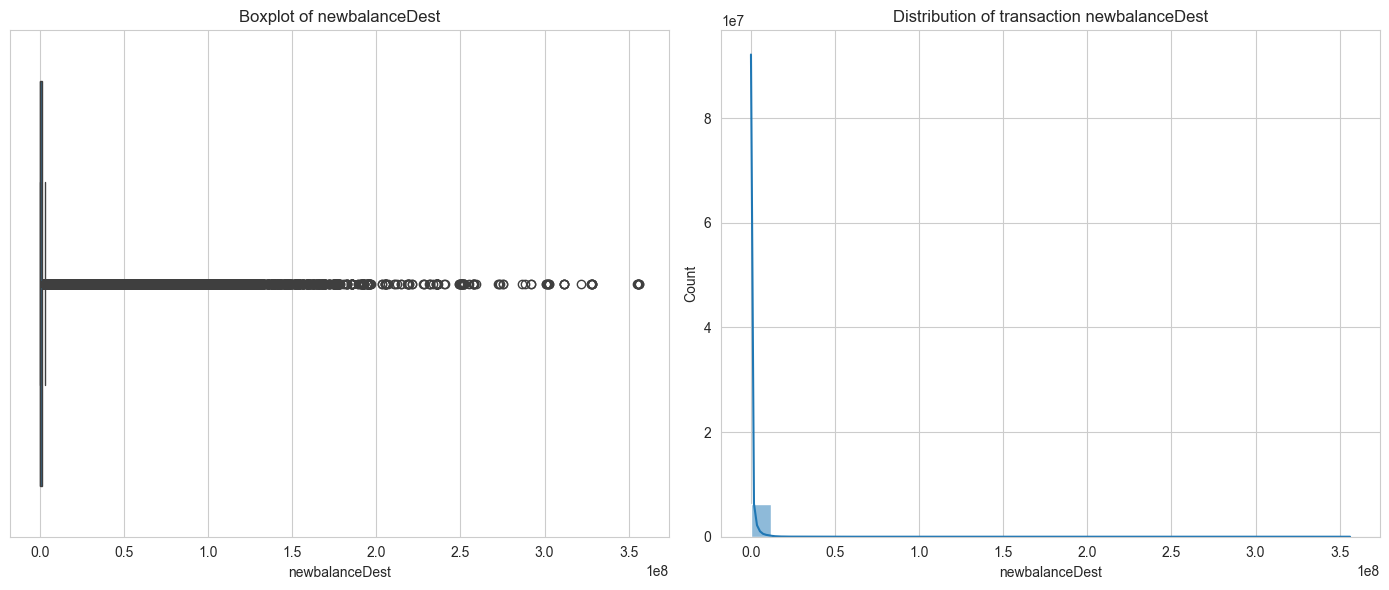

In [21]:
col = 'newbalanceDest'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of recipient balances after transactions is highly right-skewed.

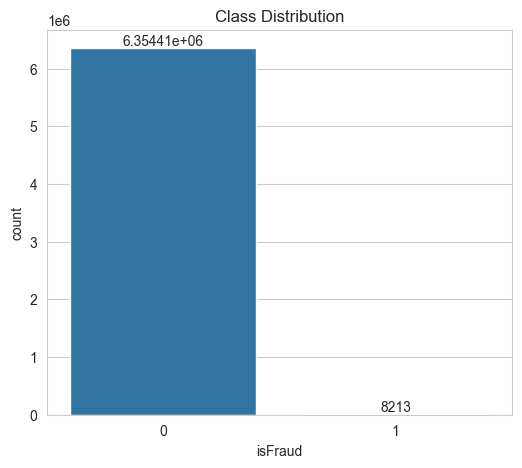

Class counts (0: Non-Fraud, 1: Fraud)
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [22]:
col = 'isFraud'

plt.figure(figsize=(6, 5))

ax = sns.countplot(x=df[col])

for container in ax.containers:
    ax.bar_label(container)

plt.title('Class Distribution')
plt.show()

print('Class counts (0: Non-Fraud, 1: Fraud)')
print(df[col].value_counts())

del ax

- The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions.

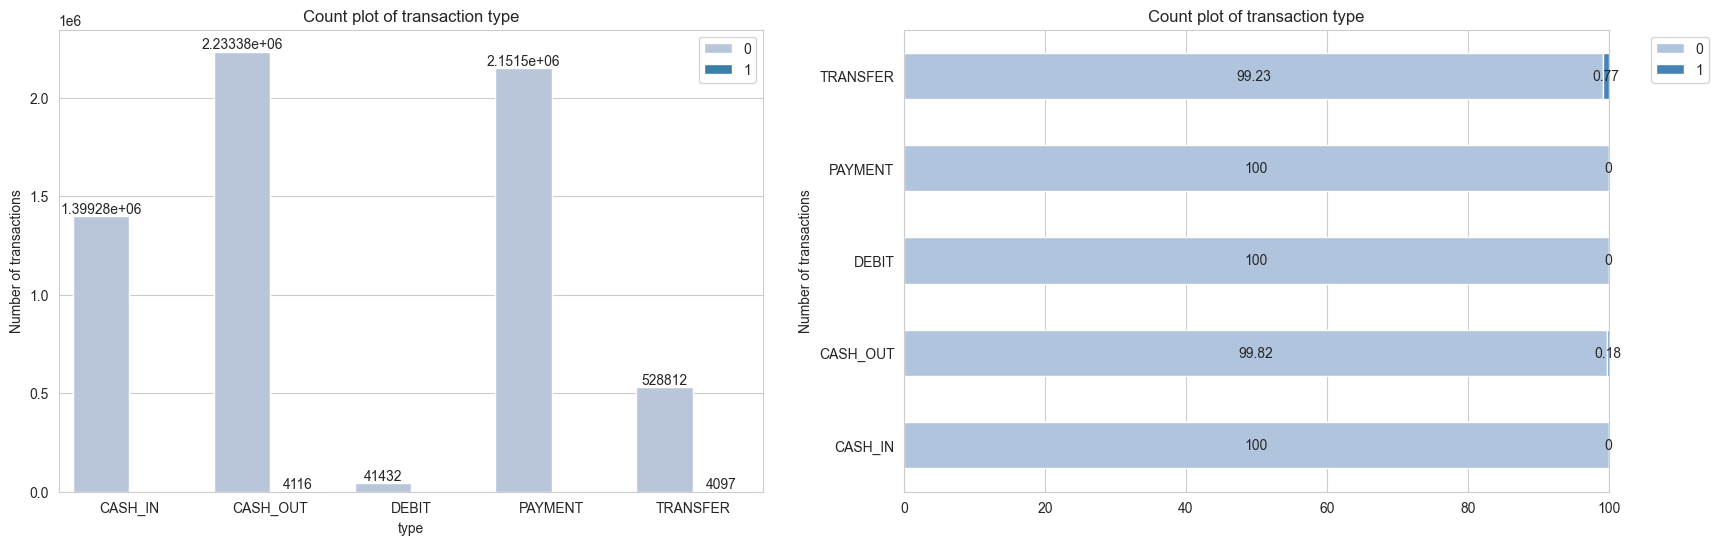

In [23]:
fig, ax = plt.subplots(1,2,figsize=(20,6))

sns.countplot(x='type', data=df, hue='isFraud', palette='PuBu', ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container)
ax[0].set_title('Count plot of transaction type')
ax[0].legend(loc='best')
ax[0].set_ylabel('Number of transactions')

df2 = df.groupby(['type', 'isFraud']).size().unstack(fill_value= 0)
df2.apply(lambda x : round(x/sum(x)*100, 2), axis=1).plot(kind='barh', stacked=True, color=['lightsteelblue', 'steelblue'], ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, label_type='center')
ax[1].set_title('Count plot of transaction type')
ax[1].legend(bbox_to_anchor=(1.05,1), loc='upper left')
ax[1].set_ylabel('Number of transactions')
ax[1].grid(axis='y')

- Fraudulent transactions occur primarily in Transfer and Cash Out transaction types.

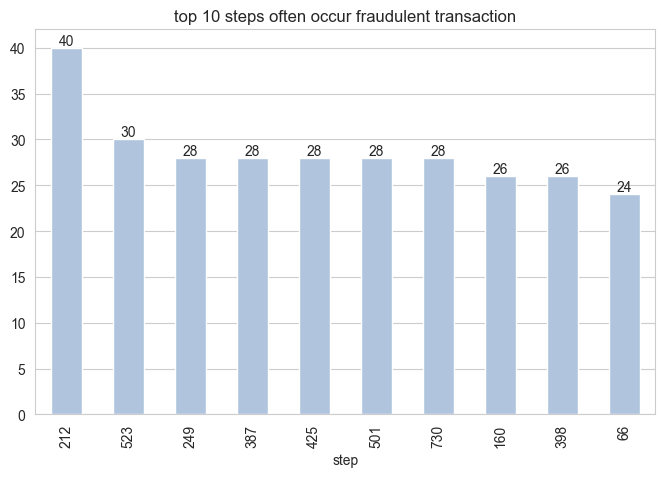

In [24]:
df1 = df[df['isFraud'] == 1]
df2 = df1['step'].value_counts().head(10)
plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')
for container in ax.containers:
    ax.bar_label(container)
plt.title('top 10 steps often occur fraudulent transaction')
plt.grid(axis= 'x')
plt.show()

del ax, df2

- Step 212 contains the highest number of fraudulent transactions, with 40 recorded cases.

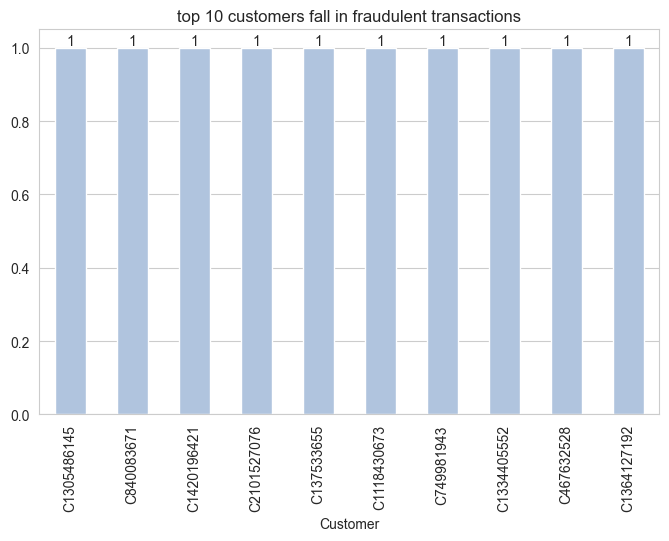

In [25]:
df2 = df1['nameOrig'].value_counts().head(10)
plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')
ax.set_xlabel('Customer')

for container in ax.containers:
    ax.bar_label(container)

plt.title('top 10 customers fall in fraudulent transactions')
plt.grid(axis= 'x')
plt.show()

- Most customers appear in fraudulent transactions only once.

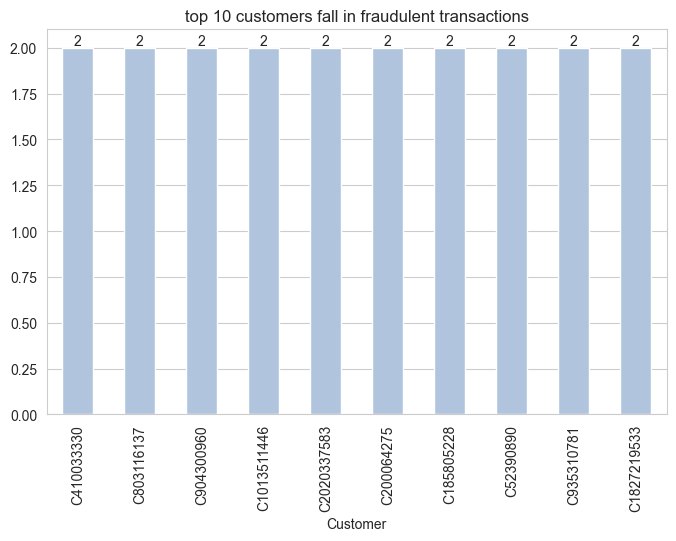

In [26]:
df2 = df1['nameDest'].value_counts().head(10)
plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')
ax.set_xlabel('Customer')

for container in ax.containers:
    ax.bar_label(container)

plt.title('top 10 customers fall in fraudulent transactions')
plt.grid(axis= 'x')
plt.show()

- Most fraudulent recipients are associated with transactions involving at most two customers.

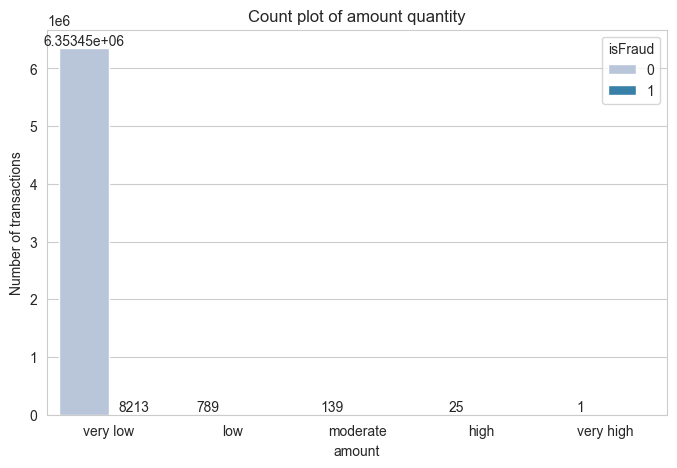

In [27]:
df['quantity'] = pd.cut(df['amount'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'quantity', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of amount quantity')
plt.ylabel('Number of transactions')
plt.xlabel('amount')
plt.show()

- Most fraudulent transactions occur within the very low transaction amount range.

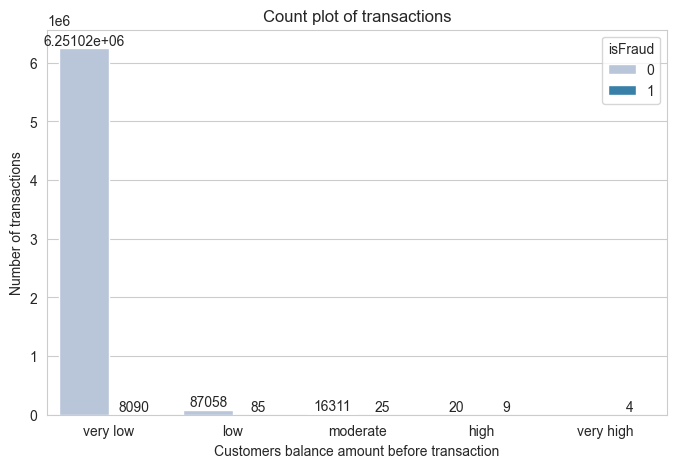

In [28]:
df['oldbalanceOrg_amount'] = pd.cut(df['oldbalanceOrg'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'oldbalanceOrg_amount', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of transactions')
plt.ylabel('Number of transactions')
plt.xlabel('Customers balance amount before transaction')
plt.show()

- Customers with very low account balances are associated with the highest number of fraudulent transactions.

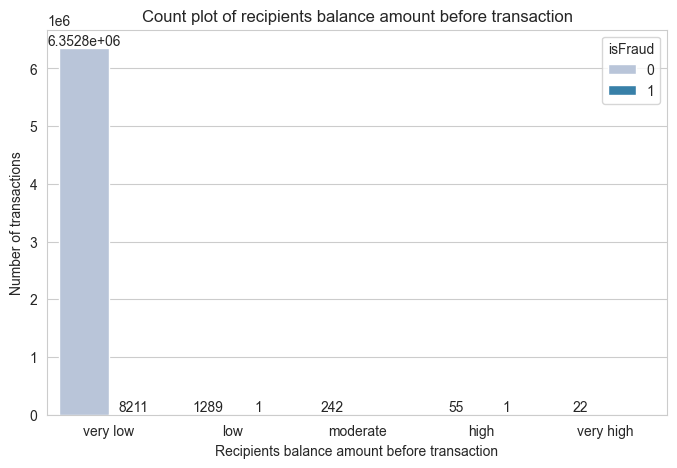

In [29]:
df['oldbalanceDest_amount'] = pd.cut(df['oldbalanceDest'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'oldbalanceDest_amount', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of recipients balance amount before transaction')
plt.ylabel('Number of transactions')
plt.xlabel('Recipients balance amount before transaction')
plt.show()

- Most fraudulent recipients have very low account balances.

### Multivariate data visualization

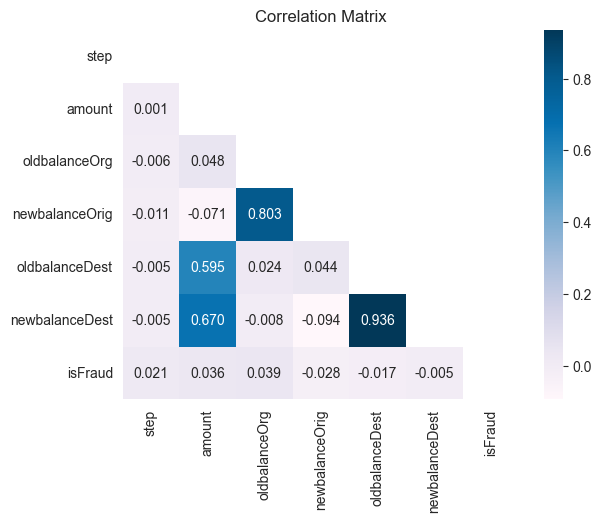

In [32]:
corr = df[numberic_cols].corr('spearman')
sns.heatmap(corr, cbar= True, annot=True, fmt='.3f', cmap= 'PuBu', mask= np.triu(np.ones_like(corr, dtype= bool)))
plt.grid(False)
plt.title('Correlation Matrix')
plt.show()

- oldbalanceOrg and newbalanceOrig show a **strong positive** correlation.
- newbalanceDest and oldbalanceDest exhibit a **strong positive** correlation.
- amount has a **moderate positive** correlation with oldbalanceDest and newbalanceDest.
- amount has a **weak positive** correlation with oldbalanceOrg.

## Preprocessing

In [39]:
# df.drop(['quantity', 'oldbalanceOrg_amount', 'oldbalanceDest_amount'], axis=1, inplace=True)
df = pd.get_dummies(data= df, columns=['type'], dtype= 'int', drop_first= True)
df

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,0,1,0
1,1,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,0,1,0
2,1,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,0,0,1
3,1,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,1,0,0,0
4,1,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,1,0,0,0
6362616,743,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,0,0,1
6362617,743,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,1,0,0,0
6362618,743,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,0,0,1
